In [1]:
# Set working directory
import os
os.chdir("../../")

In [2]:
# Configure paths

# Footprint filepaths (see analysis code for calculation)
atf1_footprint_filepath = "../Experimental_data_analysis/fimo_footprints/hocomoco_default_pthreshold/representative_hoco_motif/raw_signals/ATF1_raw_windows.csv"
atf2_footprint_filepath = "../Experimental_data_analysis/fimo_footprints/hocomoco_default_pthreshold/representative_hoco_motif/raw_signals/ATF2_raw_windows.csv"

# Motif binding filepaths (see analysis code for calculation)
atf1_motif_binding_filepath = "binding_score_at_motifs/ATF1/ATF1__orig-human__loc-prom__motif-BATF3.H12CORE.2.SM.B__type-family__fl25__nuc-7-25-50__trim150.csv"
atf2_motif_binding_filepath = "binding_score_at_motifs/ATF2/ATF2__orig-human__loc-prom__motif-BATF3.H12CORE.2.SM.B__type-family__fl25__nuc-7-25-50__trim150.csv"

## Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter

## Load data

In [4]:
atf1_fp = pd.read_csv(atf1_footprint_filepath, index_col=0)
atf1_motif_binding = pd.read_csv(atf1_motif_binding_filepath)
atf1_motif_binding["motif_name_in_fpdf"] = (atf1_motif_binding["sequence_name"].str.cat(atf1_motif_binding["start"].astype(int).astype(str),sep="_"))
atf1_motif_binding = atf1_motif_binding[atf1_motif_binding["motif_name_in_fpdf"].isin(atf1_fp.index)]


atf2_fp = pd.read_csv(atf2_footprint_filepath, index_col=0)
atf2_motif_binding = pd.read_csv(atf2_motif_binding_filepath)
atf2_motif_binding["motif_name_in_fpdf"] = (atf2_motif_binding["sequence_name"].str.cat(atf2_motif_binding["start"].astype(int).astype(str),sep="_"))
atf2_motif_binding = atf2_motif_binding[atf2_motif_binding["motif_name_in_fpdf"].isin(atf2_fp.index)]

## Plot

8
35
73


/tmp/ipykernel_881463/3281605779.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


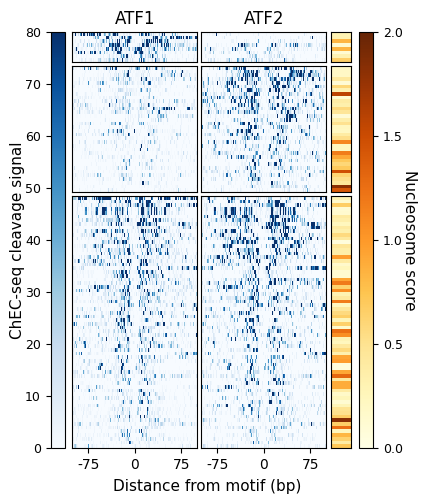

In [5]:
# Define position columns spanning -100 to +100 around motif
cols = [f"pos_{i}" for i in range(-100, 101)]

# Merge ATF1 and ATF2 motif binding tables on motif identifier
m = (atf1_motif_binding[["motif_name_in_fpdf", "z_score_norm_f7", "nuc_score_f7"]]
     .merge(atf2_motif_binding[["motif_name_in_fpdf", "z_score_norm_f7"]],
            on="motif_name_in_fpdf", suffixes=("_1", "_2")))

# Define three groups of motifs based on binding patterns
# Group 1: strong ATF1 binding, weak ATF2
g1 = m.query("z_score_norm_f7_1 > 3 & z_score_norm_f7_2 < 2")["motif_name_in_fpdf"]
print(len(g1))

# Group 2: strong ATF2 binding, weak ATF1
g2 = m.query("z_score_norm_f7_2 > 3 & z_score_norm_f7_1 < 2")["motif_name_in_fpdf"]
print(len(g2))

# Group 3: moderately bound by both, excluding g1 and g2
mask3 = (
    (m["z_score_norm_f7_1"] > 1) &
    (m["z_score_norm_f7_2"] > 1) &
    ~m["motif_name_in_fpdf"].isin(pd.concat([g1, g2]))
)
g3 = m.loc[mask3, "motif_name_in_fpdf"]
print(len(g3))


# Compute total footprint signal per motif for ranking
row_sums1 = atf1_fp[cols].sum(axis=1)
row_sums2 = atf2_fp[cols].sum(axis=1)

# Sort motifs within each group by signal strength
g1_order = row_sums1.loc[g1].sort_values(ascending=False).index
g2_order = row_sums2.loc[g2].sort_values(ascending=False).index
g3_order = (row_sums1 + row_sums2).loc[g3].sort_values(ascending=False).index

# Extract nucleosome scores aligned to motif names
nuc = m.set_index("motif_name_in_fpdf")["nuc_score_f7"]


# Helper: extract footprint matrices and nucleosome scores for a group
def group_mats(idx):
    # Subset footprint matrices
    h1g = atf1_fp.loc[idx, cols]
    h2g = atf2_fp.loc[idx, cols]

    # Keep only rows without missing values in either matrix
    valid = ~(h1g.isna().any(axis=1) | h2g.isna().any(axis=1))

    # Subset nucleosome scores
    nucg = nuc.loc[idx]

    return h1g.loc[valid], h2g.loc[valid], nucg.loc[valid]


# Build grouped matrices for all three motif classes
h1_groups, h2_groups, nuc_groups = zip(
    *(group_mats(idx) for idx in [g1_order, g2_order, g3_order])
)

# Use group sizes to control vertical panel heights
hr = [len(h) for h in h1_groups]


# Create 3x3 panel layout:
# columns = ATF1, ATF2, nucleosome score
fig, axes = plt.subplots(
    3, 3,
    figsize=(3.6, 5.4),
    sharex=False,
    gridspec_kw={
        "wspace": 0.05,
        "hspace": 0.03,
        "height_ratios": hr,
        "width_ratios": [1, 1, 1/6],
    }
)

nuc_im = None  # will store imshow handle for colorbar

# Plot each group
for i, (h1g, h2g, nucg) in enumerate(zip(h1_groups, h2_groups, nuc_groups)):
    ax1, ax2, axn = axes[i]

    # Plot footprint heatmaps for ATF1 and ATF2
    ax1.imshow(h1g.to_numpy(), aspect="auto", cmap="Blues", vmax=80, interpolation="nearest")
    ax2.imshow(h2g.to_numpy(), aspect="auto", cmap="Blues", vmax=80, interpolation="nearest")

    # Plot nucleosome score as a vertical strip
    nuc_im = axn.imshow(
        nucg.to_numpy()[:, None],
        aspect="auto",
        cmap="YlOrBr",
        vmin=0,
        vmax=2,
        interpolation="nearest"
    )

    # Ensure both footprint panels share the same x-axis limits
    ax2.sharex(ax1)
    ax1.set_xlim(-0.5, len(cols) - 0.5)
    ax2.set_xlim(-0.5, len(cols) - 0.5)

    # Nucleosome column is a single column
    axn.set_xlim(-0.5, 0.5)

    # Add column titles on top row
    if i == 0:
        ax1.set_title("ATF1")
        ax2.set_title("ATF2")


# Remove all y-axis ticks (clean heatmap look)
for ax in axes.ravel():
    ax.set_yticks([])

# Hide x-axis ticks for all but bottom row
for ax in axes[:-1, :].ravel():
    ax.tick_params(axis="x", bottom=False, labelbottom=False)

# Add labeled x-ticks only on bottom footprint panels
positions = [-75, 0, 75]
xticks = [cols.index(f"pos_{p}") for p in positions]
for ax in axes[-1, [0, 1]]:
    ax.set_xticks(xticks)
    ax.set_xticklabels(positions)

# Remove ticks from nucleosome column
axes[-1, 2].set_xticks([])
axes[-1, 2].set_xticklabels([])


# ---- Add skinny colorbar for nucleosome score ----
fig.canvas.draw()  # ensure layout positions are updated
bbox = axes[0, 2].get_position()

# Create colorbar axis to the right of nucleosome panels
cax = fig.add_axes([bbox.x1 + 0.02, 0.11, 0.04, 0.77])
cbar = fig.colorbar(nuc_im, cax=cax)

# Set fixed tick positions and formatting
ticks = [0.0, 0.5, 1.0, 1.5, 2.0]
cbar.set_ticks(ticks)
cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))

# Label and style colorbar
cbar.set_label("Nucleosome score", rotation=270, labelpad=10, fontsize=11)
cbar.ax.tick_params(labelsize=9)

# ---- Add skinny colorbar for binding signal (left side) ----
bbox_left = axes[0, 0].get_position()
cax_left = fig.add_axes([bbox_left.x0 - 0.06, 0.11, 0.04, 0.77])
binding_im = axes[0, 0].images[0]
cbar_left = fig.colorbar(binding_im, cax=cax_left)
cbar_left.ax.yaxis.set_ticks_position('left')
cbar_left.ax.yaxis.set_label_position('left')
cbar_left.set_label("ChEC-seq cleavage signal", labelpad=0, fontsize=11)
cbar_left.ax.tick_params(labelsize=9)

# Global x-axis label for the entire figure
fig.supxlabel("Distance from motif (bp)", fontsize=11, y=0.025)

plt.tight_layout()
plt.show()